In [1]:
import os
import georaster
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np

from whale_gunshot_localization import config

### Experimental Site Figure

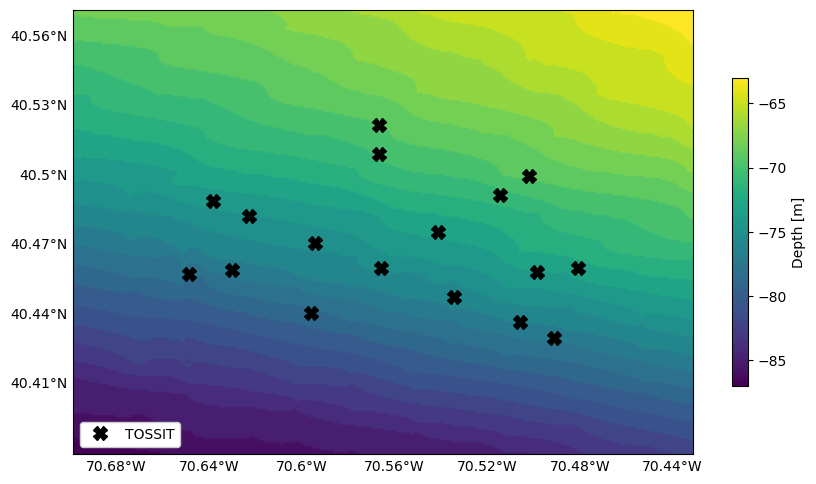

In [55]:
# buffer
b = 0.05

# get TOSSIT position
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
miny= TOSSIT_latlons[:,0].min()
maxy= TOSSIT_latlons[:,0].max()
minx= TOSSIT_latlons[:,1].min()
maxx= TOSSIT_latlons[:,1].max()

fig = plt.figure(figsize=(10,10))
m = Basemap(projection='cyl',
            llcrnrlon=minx-b,
            llcrnrlat=miny-b,
            urcrnrlon=maxx+b,
            urcrnrlat=maxy+b,
            resolution='i')
m.drawcoastlines(color="gray")
m.fillcontinents(color='beige')

# load the geotiff image, assign it a variable
image = georaster.SingleBandRaster(os.path.join(config['dataset']['data_directory'], 'mikesbathym.tif'),
                                   load_data=(minx-b, maxx+b, miny-b, maxy+b),
                                   latlon=True)
m.drawparallels(np.around(np.arange(miny-b, maxy+b, 0.03), 2), labels=[1, 0, 0, 0], fontsize=10, color="None")
m.drawmeridians(np.around(np.arange(minx-b+0.02, maxx+b+0.02, 0.04), 2), labels=[0, 0, 0, 1], fontsize=10, color="None")
plt.imshow(-1*image.r, extent=(minx-b, maxx+b, miny-b, maxy+b), zorder=1)
plt.plot(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0], 'kX', markersize=10, label="TOSSIT")
plt.colorbar(location='right', shrink=0.4, label='Depth [m]')
plt.legend(framealpha=1.0)
plt.show()